In [ ]:
# Install required packages
!pip install -q kaggle scikit-learn matplotlib

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [ ]:
# Upload your kaggle.json file (download from your Kaggle account settings)
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nipungarg1409","key":"fe675e10b2f386c6b37b64dd9778c0bd"}'}

In [ ]:
# Move it to the correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download the Cleveland dataset
!kaggle datasets download -d cherngs/heart-disease-cleveland-uci

# Unzip the dataset
!unzip heart-disease-cleveland-uci.zip

# Load the CSV file
df = pd.read_csv("heart_cleveland_upload.csv")  # Adjust filename if needed
df.head()

Dataset URL: https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci
License(s): reddit-api
100% 3.33k/3.33k [00:00<00:00, 9.30MB/s]

Archive:  heart-disease-cleveland-uci.zip
  inflating: heart_cleveland_upload.csv  


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [ ]:
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
df = df.apply(pd.to_numeric)

In [ ]:
X = df.drop(['condition'], axis=1)
y = df['condition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
pipeline = Pipeline([('model', RandomForestClassifier(random_state=42))])

In [ ]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 5, 10],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2]
}

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)

Best Parameters: {'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV F1 Score: 0.7792261664391157


In [ ]:
y_proba = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
print("Optimal Threshold:", optimal_threshold)

Optimal Threshold: 0.4063707899683797


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
y_pred= (y_proba >= optimal_threshold).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUROC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Accuracy: 0.8666666666666667
Precision: 0.8846153846153846
Recall: 0.8214285714285714
F1 Score: 0.8518518518518519
AUROC: 0.9241071428571428
              precision    recall  f1-score   support

           0       0.85      0.91      0.88        32
           1       0.88      0.82      0.85        28

    accuracy                           0.87        60
   macro avg       0.87      0.86      0.87        60
weighted avg       0.87      0.87      0.87        60



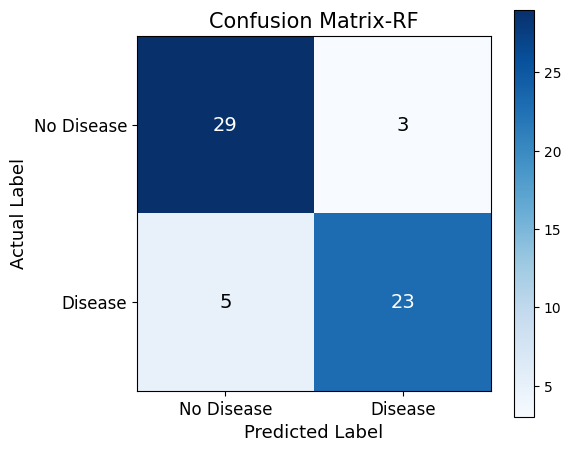

In [ ]:
# ----- CONFUSION MATRIX -----
# y_test: ground truth, y_pred: predicted class labels
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix-RF', fontsize=15)
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ['No Disease', 'Disease'], fontsize=12)
plt.yticks(tick_marks, ['No Disease', 'Disease'], fontsize=12)
plt.xlabel('Predicted Label', fontsize=13)
plt.ylabel('Actual Label', fontsize=13)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=14)
plt.tight_layout()
plt.grid(False)
plt.show()

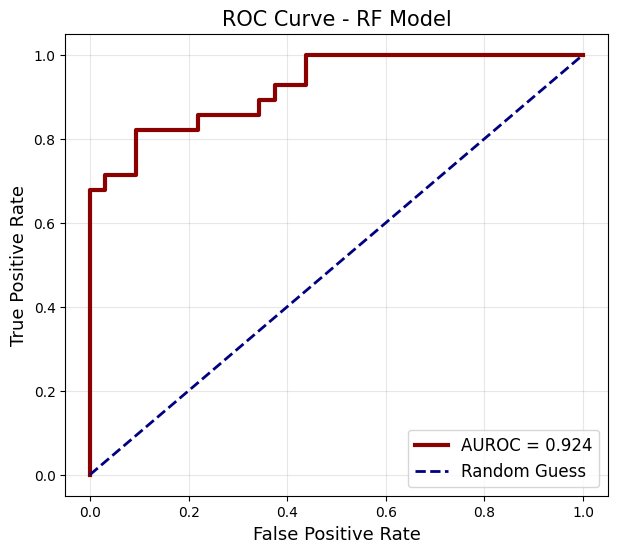

In [ ]:
from sklearn.metrics import auc

# ----- ROC CURVE -----
# y_test: ground truth labels
# y_proba: predicted probabilities for positive class (model.predict_proba(X_test)[:,1])
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_value = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkred', lw=3, label=f'AUROC = {auc_value:.3f}')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('ROC Curve - RF Model', fontsize=15)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# ----- Predict for a random patient -----
import random
rand_index = random.randint(0, X_test.shape[0]-1)
patient_features = X_test.iloc[rand_index].values.reshape(1, -1)
true_label = y_test.iloc[rand_index]
pred_prob = best_model.predict_proba(patient_features)[0][1]
pred_class = int(pred_prob >= optimal_threshold)
print("\nRandom Patient Details:")
print(X_test.iloc[rand_index])

print("\nTrue Condition:", "Heart Disease" if true_label == 1 else "No Disease")
print(f"Predicted Probability of Heart Disease: {pred_prob*100:.2f}%")
print("Predicted Class:", "Heart Disease" if pred_class == 1 else "No Disease")


Random Patient Details:
age          59.0
sex           1.0
cp            3.0
trestbps    110.0
chol        239.0
fbs           0.0
restecg       2.0
thalach     142.0
exang         1.0
oldpeak       1.2
slope         1.0
ca            1.0
thal          2.0
Name: 208, dtype: float64

True Condition: Heart Disease
Predicted Probability of Heart Disease: 87.84%
Predicted Class: Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
import joblib
import os

# Save the best RF model (pure RandomForest, no scaler inside)
os.makedirs('pkl_files', exist_ok=True)
joblib.dump(best_model, 'pkl_files/rf.pkl')

# Verify
loaded = joblib.load('pkl_files/rf.pkl')
test_prob = loaded.predict_proba(X_test[:1])[0][1]
print(f"RF pkl verified. Sample prob: {test_prob:.4f}")
print(f"Optimal threshold locked: {optimal_threshold:.4f}")
print("RF model saved successfully.")

RF pkl verified. Sample prob: 0.1822
Optimal threshold locked: 0.4064
RF model saved successfully.
